In [1]:
# Importing Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

In [2]:
# Load Dataset

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Dataset Information

print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 7043
Columns: 21


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [7]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [11]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [12]:
df['TotalCharges'].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

In [13]:
df[df['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [14]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

In [15]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [16]:
df.dropna(inplace=True)

In [17]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [18]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'])

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [20]:
df.drop('customerID',axis=1,inplace=True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

In [22]:
#EDA 
print(df['Churn'].value_counts())
df['Churn'].value_counts(normalize=True)

Churn
No     5163
Yes    1869
Name: count, dtype: int64


Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

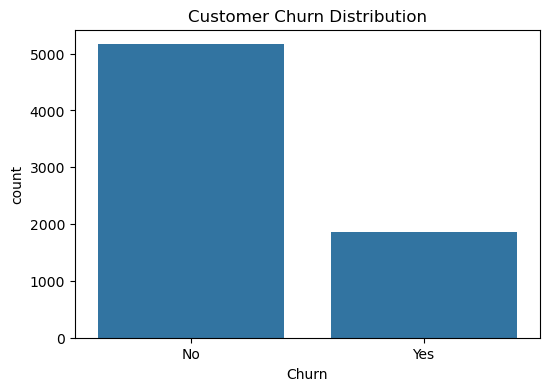

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")

plt.show()

In [24]:
#BUSINESS INSIGHT 

#The company retains most of its customers.
#Reducing churn by  a small percentage could improve customer retention.

In [25]:
print(df['Contract'].value_counts())
df['Contract'].value_counts(normalize=True)

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64


Contract
Month-to-month    0.551052
Two year          0.239619
One year          0.209329
Name: proportion, dtype: float64

In [26]:
pd.crosstab(df['Contract'], df['Churn'])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


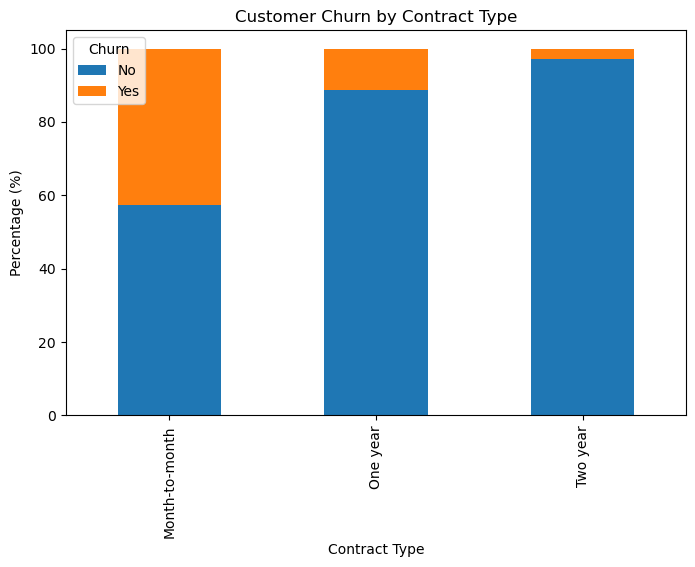

In [27]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")
plt.show()

In [28]:
#BUSINESS INSIGHT

#Contract type has a strong influence on customer retention.
#Encouraging month-to-month customers to upgrade to longer-term plans through discounts or loyalty programs.

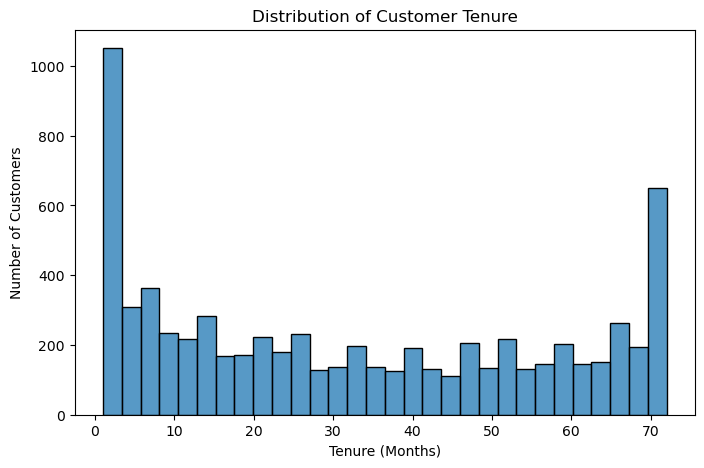

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df['tenure'], bins=30)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

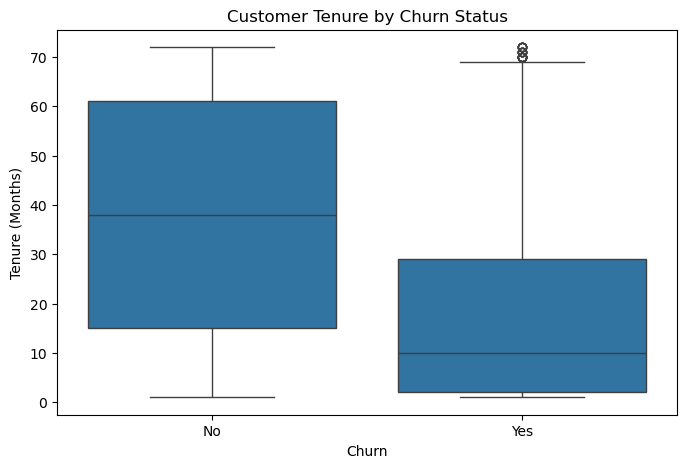

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [31]:
#BUSINESS INSIGHT 

#The comapny has large no. of new and long term customers.
#The company should focus on improving experience iof the new user, that will help the in long term. 

In [32]:
# Customer Churn by Gender

gender_churn_percentage = pd.crosstab(
    df['gender'],
    df['Churn'],
    normalize='index'
) * 100

gender_churn_percentage

Churn,No,Yes
gender,,
Female,73.040482,26.959518
Male,73.795435,26.204565


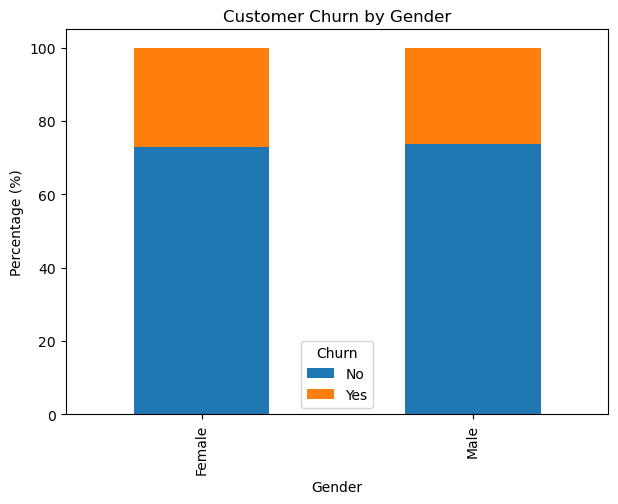

In [33]:
gender_churn_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(7,5)
)

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")
plt.show()

In [34]:
#BUSINESS INSIGHT

#Gender does not appear to influence customer churn.
#This suggests that retention strategies should focus on customer behavior and service-related factors rather than gender demographics.

In [35]:
# Customer Churn by Senior Citizen

senior_citizen_churn_percentage = pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
) * 100

senior_citizen_churn_percentage

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


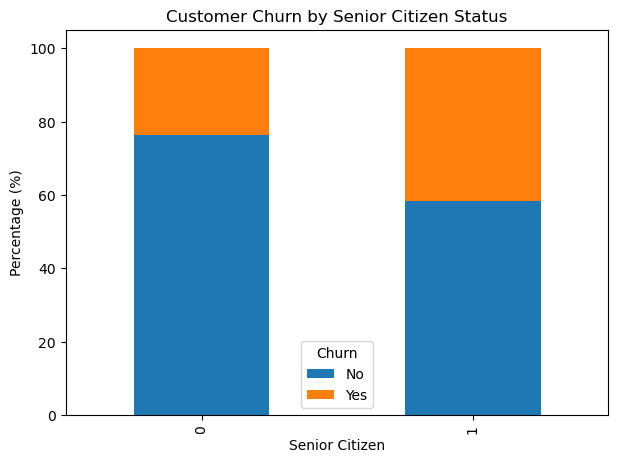

In [36]:
senior_citizen_churn_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(7,5)
)

plt.title("Customer Churn by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")
plt.show()

In [37]:
#BUSINESS INSIGHT

#Senior citizens exhibit a higher churn rate compared to non-senior customers. 
#This suggests that age-related factors or customer experience may influence churn. 
#The company should investigate this segment further and consider targeted retention strategies.

In [38]:
# Customer Churn by Partner

partner_churn_percentage = pd.crosstab(
    df['Partner'],
    df['Churn'],
    normalize='index'
) * 100

partner_churn_percentage

Churn,No,Yes
Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065


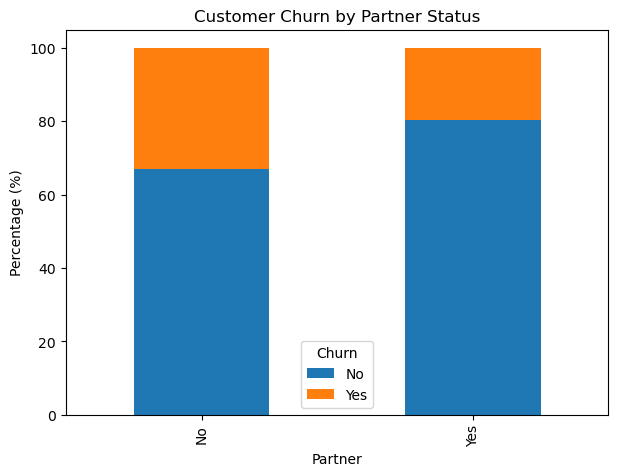

In [39]:
partner_churn_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(7,5)
)

plt.title("Customer Churn by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")
plt.show()

In [40]:
#BUSINESS INSIGHT 

#Customers with parterns show less churn rate compared to the customers without partners.
#The company can Leverage by introducing family or bundled plans.

In [41]:
# Customer Churn by Dependents

dependents_churn_percentage = pd.crosstab(
    df['Dependents'],
    df['Churn'],
    normalize='index'
) * 100

dependents_churn_percentage

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.468795,15.531205


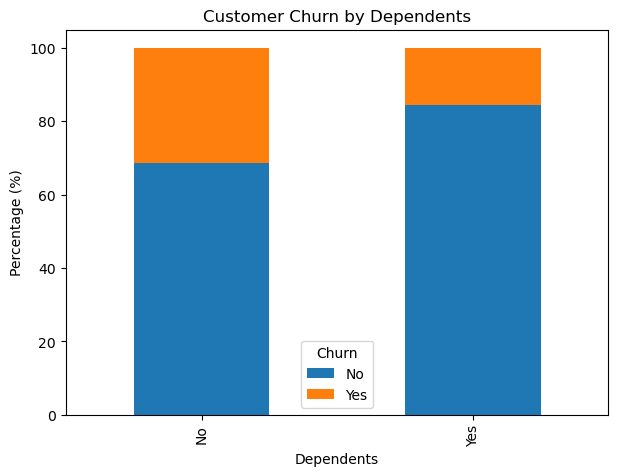

In [42]:
dependents_churn_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(7,5)
)

plt.title("Customer Churn by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")

plt.show()

In [43]:
#BUSINESS INSIGHT

#Customers wityh dependents are likely to churn less

In [44]:
# Customer Churn by Internet Service

internet_service_churn_percentage = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

internet_service_churn_percentage

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


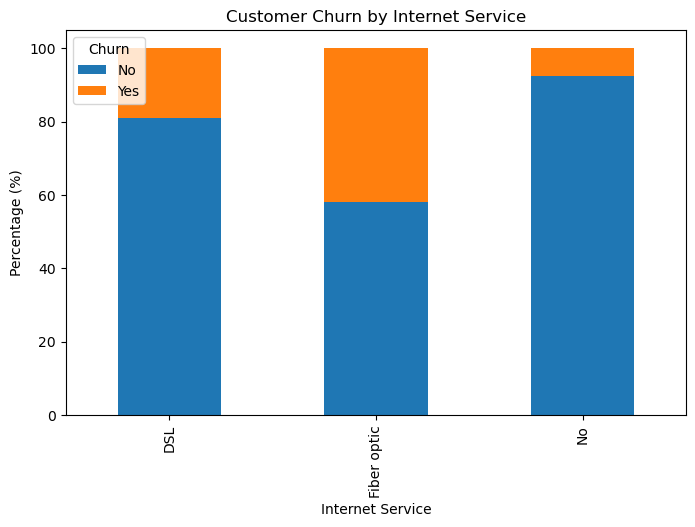

In [45]:
internet_service_churn_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")

plt.show()

In [46]:
#BUSINESS INSIGHT

#Fiber optic customers exhibit the highest churn rate among all internet service categories.  
#The company should focus on improving service quality and offering loyalty benefits to retain these high-value customers.

In [47]:
# Customer Churn by Payment Method

payment_method_churn_percentage = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

payment_method_churn_percentage

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


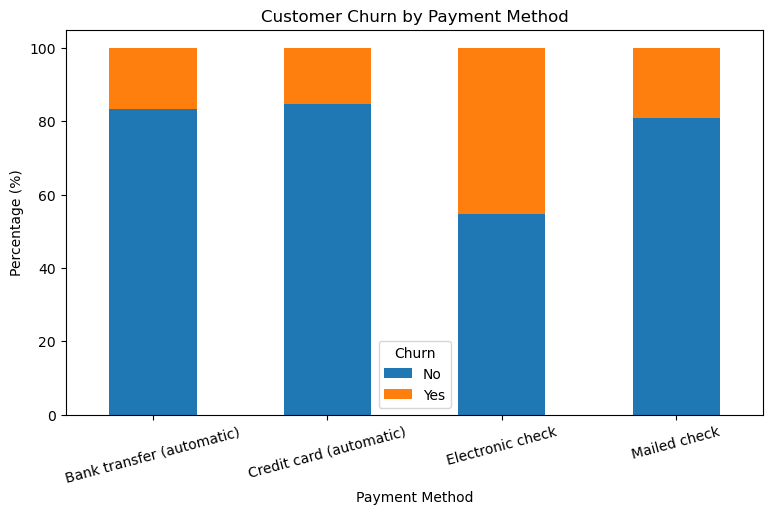

In [48]:
payment_method_churn_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(9,5)
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")

plt.xticks(rotation=15)

plt.show()

In [49]:
#BUSINESS INSIGHT
 
#Since manual payment methods require customers to complete payments themselves each billing cycle, they may be more likely to discontinue the service.
#The company can encourage customers to switch to automatic payment methods by offering incentives such as discounts, cashback, or exclusive benefits.

In [50]:
# Customer Churn by Paperless Billing
paperless_churn_percentage = pd.crosstab(
    df['PaperlessBilling'],
    df['Churn'],
    normalize='index'
) * 100

paperless_churn_percentage

Churn,No,Yes
PaperlessBilling,,
No,83.624302,16.375698
Yes,66.410749,33.589251


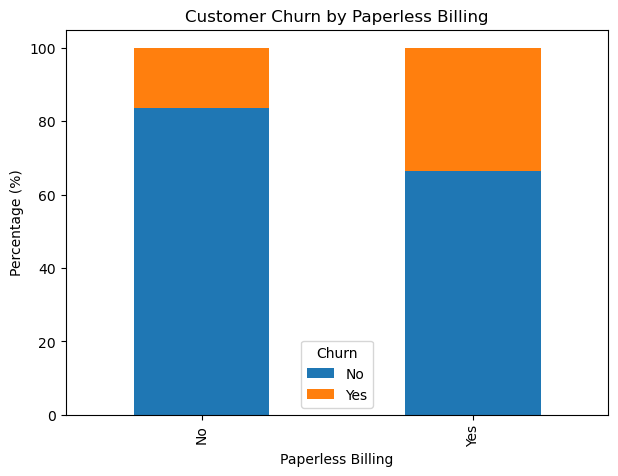

In [51]:
paperless_churn_percentage.plot(
    kind='bar',
    stacked=True,
    figsize=(7,5)
)

plt.title("Customer Churn by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Percentage (%)")
plt.legend(title="Churn")

plt.show()

In [52]:
#BUSINESS INSIGHT

#Customers using paperless billing show a higher churn rate than customers receiving paper bills.
#Improving customer engagement through these digital touchpoints may strengthen customer relationships and reduce churn.

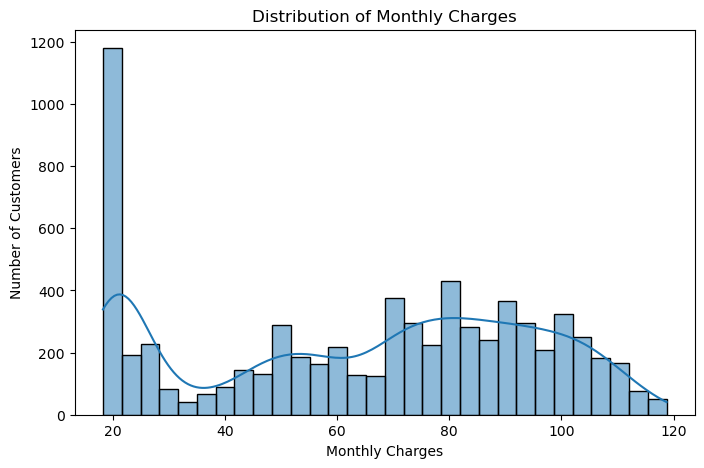

In [53]:
# Monthly Charges Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyCharges'], bins=30, kde=True)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of Customers")

plt.show()

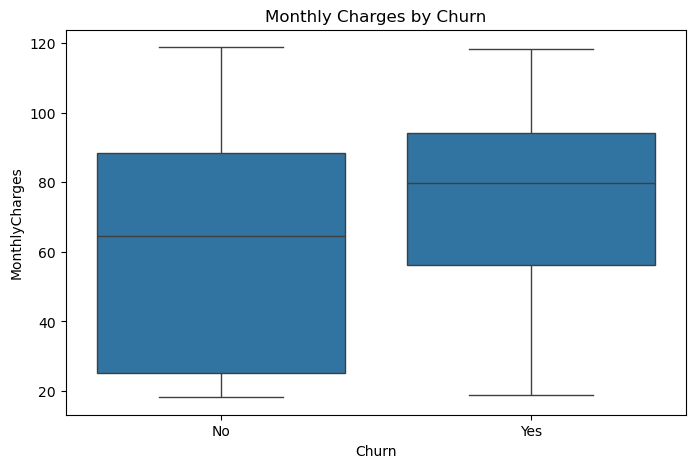

In [54]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df
)

plt.title("Monthly Charges by Churn")


plt.show()

In [55]:
#BUSINESS INSIGHT

#This indicates that monthly charges are associated with churn but are not sufficient on their own to predict it.

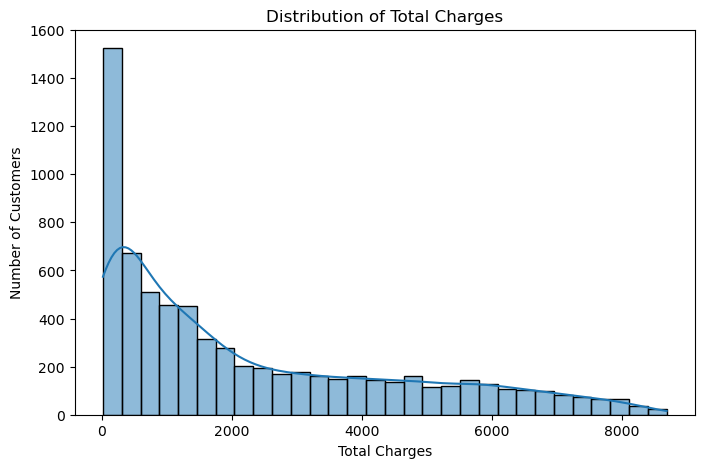

In [56]:
# Distribution of Total Charges

plt.figure(figsize=(8,5))

sns.histplot(df['TotalCharges'], bins=30, kde=True)

plt.title("Distribution of Total Charges")
plt.xlabel("Total Charges")
plt.ylabel("Number of Customers")

plt.show()

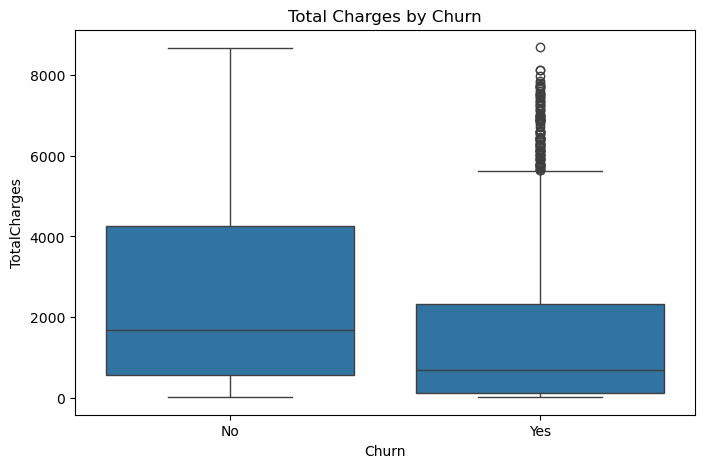

In [57]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='TotalCharges',
    data=df
)

plt.title("Total Charges by Churn")

plt.show()

In [58]:
#Customers with lower total charges are more likely to churn, while customers who have spent more over time tend to remain with the company. This indicates that long-term customers are generally more loyal. The company should focus on improving the experience of new customers during their initial months to encourage long-term retention.


In [59]:
# Select numerical columns
numerical_df = df.select_dtypes(include=['int64', 'float64'])

numerical_df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65


In [60]:
correlation_matrix = numerical_df.corr()

correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


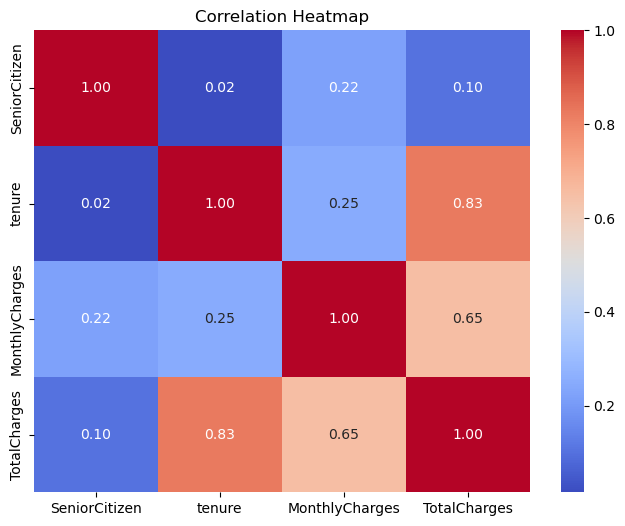

In [61]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

In [62]:
 df.dtypes


gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [63]:
df['OnlineSecurity'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

In [64]:
df['MultipleLines'].unique()

array(['No phone service', 'No', 'Yes'], dtype=object)

In [65]:
# Replace redundant values

replace_cols = [
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in replace_cols:
    df[col] = df[col].replace({
        'No internet service': 'No',
        'No phone service': 'No'
    })

In [66]:
df['OnlineSecurity'].unique()

array(['No', 'Yes'], dtype=object)

In [67]:
binary_cols = [
    'gender',
    'Partner',
    'Dependents',
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'PaperlessBilling',
    'Churn'
]

In [68]:
# Binary Encoding
for col in binary_cols:
    df[col] = df[col].replace({
        'Yes': 1,
        'No': 0
    })

# Gender Encoding
df['gender'] = df['gender'].replace({
    'Male': 1,
    'Female': 0
})

In [69]:
# One-Hot Encoding

df = pd.get_dummies(
    df,
    columns=[
        'InternetService',
        'Contract',
        'PaymentMethod'
    ],
    drop_first=True
)

In [70]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,False,False,True,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,False,False,True,False,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,True,False,False,False,False,True,False


In [71]:
df.dtypes


gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
MultipleLines                              int64
OnlineSecurity                             int64
OnlineBackup                               int64
DeviceProtection                           int64
TechSupport                                int64
StreamingTV                                int64
StreamingMovies                            int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
InternetService_Fiber optic                 bool
InternetService_No                          bool
Contract_One year                           bool
Contract_Two year   

In [72]:
# Features (Independent Variables)
X = df.drop('Churn', axis=1)

# Target (Dependent Variable)
y = df['Churn']

In [73]:
print(X.shape)

print(y.shape)

(7032, 23)
(7032,)


In [74]:
from sklearn.model_selection import train_test_split

# Split the dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [75]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 23)
(1407, 23)
(5625,)
(1407,)


In [76]:
from sklearn.linear_model import LogisticRegression

In [77]:
log_model = LogisticRegression(max_iter=1000)

In [78]:
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [79]:
y_pred = log_model.predict(X_test)

In [80]:
y_pred[:10]

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0])

In [81]:
from sklearn.metrics import accuracy_score

In [82]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 78.89%


In [83]:
from sklearn.metrics import confusion_matrix

In [84]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[918, 115],
       [182, 192]])

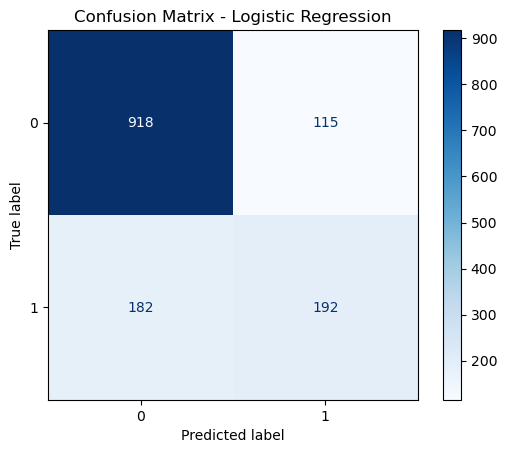

In [85]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues'
)

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [87]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

dt_accuracy = accuracy_score(y_test, dt_pred)

print(f"Decision Tree Accuracy: {dt_accuracy:.2%}")

print(classification_report(y_test, dt_pred))

Decision Tree Accuracy: 71.14%
              precision    recall  f1-score   support

           0       0.82      0.78      0.80      1033
           1       0.46      0.51      0.48       374

    accuracy                           0.71      1407
   macro avg       0.64      0.65      0.64      1407
weighted avg       0.72      0.71      0.72      1407



In [89]:
comparison = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy':[
        accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

comparison['Accuracy'] = comparison['Accuracy']*100

comparison

,Model,Accuracy
0,Logistic Regression,78.891258
1,Decision Tree,71.144279
2,Random Forest,77.825160


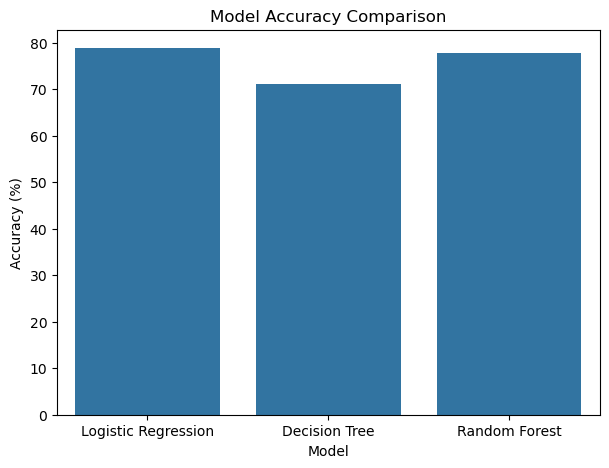

In [90]:
plt.figure(figsize=(7,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=comparison
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")

plt.show()

In [91]:
feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
15,TotalCharges,0.191245
14,MonthlyCharges,0.180979
4,tenure,0.168698
16,InternetService_Fiber optic,0.045384
21,PaymentMethod_Electronic check,0.036394
19,Contract_Two year,0.030408
0,gender,0.028224
13,PaperlessBilling,0.026407
7,OnlineSecurity,0.025118
10,TechSupport,0.024889


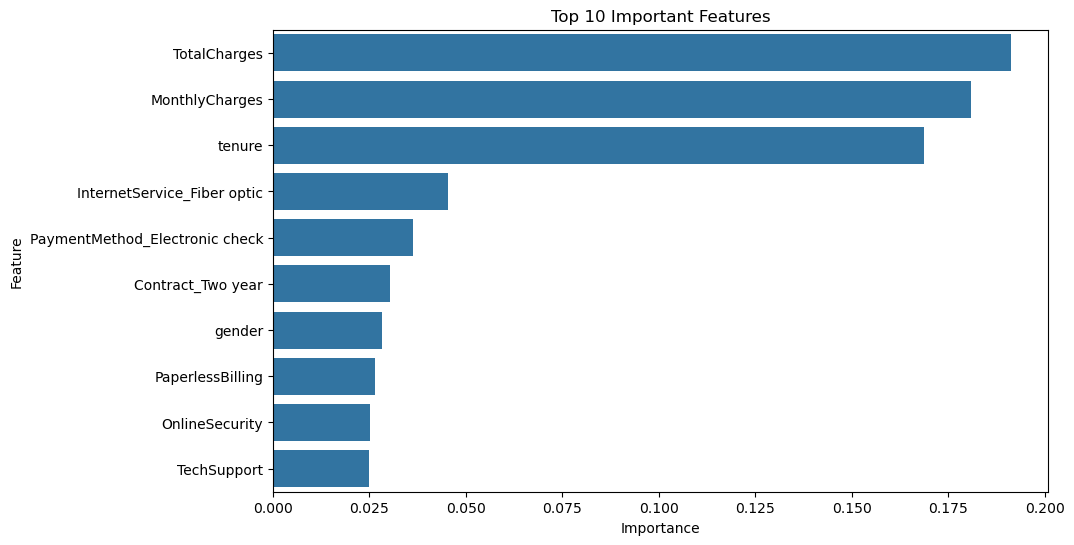

In [92]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

In [94]:
### Business Conclusion

#- Customers with month-to-month contracts showed the highest churn.
#- Customers with shorter tenure were more likely to leave.
#- Higher monthly charges increased churn probability.
#- Customers using Fiber Optic Internet had a higher churn rate.
#- Electronic Check users churned more frequently.
#- Customers with partners and dependents were less likely to churn.


In [95]:
import joblib

joblib.dump(rf_model, 'customer_churn_model.pkl')


['customer_churn_model.pkl']